# 1. Data Collection & Dataset Overview
In this study, I investigate the macroeconomic consequences of the sudden withdrawal of United States humanitarian aid in 2025 on local staple food markets in the Horn of Africa. I selected this topic because I want to work in international global organizations such as United Nations and World Bank in the future, to work of the studies about development of Africa. Currently, I am taking MGMT310 - Humanitarian Aid course. In this course, I learned the huge effect of withdrawal of US from humanitarian aid. That's why I wanted to investigate it further. Throughtout my project, I will be mentored by Dr. Asma Nairi who is the instructor of the MGMT310 course to obtain my knowledge about humanitarian aid sector. 

**Data Sources:**
1. **WFP (World Food Programme):** Monthly staple food prices (White Maize and Sorghum) in USD to control for local inflation.
2. **UN FTS (Financial Tracking Service):** Annual humanitarian aid funding volumes (in Million USD) from the US and EU.
3. **FAOSTAT:** Domestic agricultural crop production (in Million Tonnes) to control for local supply shocks.

**Dataset Characteristics:**
The final merged dataset is a structured Panel Data containing the following key variables:
* `Country`: Somalia, Ethiopia (Treatment) and Kenya (Control).
* `Year` & `Month`: Temporal variables.
* `usdprice`: Average monthly price of staple crops per KG in USD.
* `US_Aid_M` & `EU_Aid_M`: Funding volumes in Million USD.
* `Crop_Production_M_Tonnes`: Aggregate domestic supply of maize and sorghum.
* `Political_Instability`: A dummy variable controlling for regional conflicts.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# 1. WFP Fiyat Verilerini Yükleme
df_prices = pd.concat([
    pd.read_csv('wfp_food_prices_somalia.csv').assign(Country='Somalia'),
    pd.read_csv('wfp_food_prices_eth.csv').assign(Country='Ethiopia'),
    pd.read_csv('wfp_food_prices_kenya.csv').assign(Country='Kenya')
], ignore_index=True)

target_crops = ['Maize (white)', 'Maize', 'Sorghum (red)', 'Sorghum (white)', 'Sorghum']
df_prices = df_prices[df_prices['commodity'].isin(target_crops)]
df_prices['date'] = pd.to_datetime(df_prices['date'])
df_prices['Year'] = df_prices['date'].dt.year
df_prices['Month'] = df_prices['date'].dt.month

# Aylık Ortalama Fiyatlar
df_monthly = df_prices[df_prices['Year'] >= 2020].groupby(['Country', 'Year', 'Month'])['usdprice'].mean().reset_index()

# 2. FTS Yardım ve FAOSTAT Tarım Verilerini Entegre Etme (Milyon bazında)
funding_data = {
    'Somalia':  {2024: {'USA': 466.9, 'EU': 103.6}, 2025: {'USA': 70.6, 'EU': 97.1}},
    'Ethiopia': {2024: {'USA': 524.4, 'EU': 99.3},  2025: {'USA': 218.6, 'EU': 92.0}},
    'Kenya':    {2024: {'USA': 199.5, 'EU': 27.9},  2025: {'USA': 63.7, 'EU': 28.0}}
}
crop_data = {
    'Somalia':  {2024: 0.12, 2025: 0.10}, 
    'Ethiopia': {2024: 10.5, 2025: 9.80}, 
    'Kenya':    {2024: 3.20, 2025: 3.20}  
}

df_monthly['US_Aid_M'] = df_monthly.apply(lambda row: funding_data.get(row['Country'], {}).get(2025 if row['Year'] >= 2025 else 2024, {}).get('USA', 0), axis=1)
df_monthly['EU_Aid_M'] = df_monthly.apply(lambda row: funding_data.get(row['Country'], {}).get(2025 if row['Year'] >= 2025 else 2024, {}).get('EU', 0), axis=1)
df_monthly['Crop_Production_M_Tonnes'] = df_monthly.apply(lambda row: crop_data.get(row['Country'], {}).get(2025 if row['Year'] >= 2025 else 2024, 0), axis=1)

# 3. Model Değişkenleri (Difference-in-Differences & Dummy Variables)
instability_data = {'Somalia': 1, 'Ethiopia': 1, 'Kenya': 0}
df_monthly['Political_Instability'] = df_monthly['Country'].map(instability_data)

df_monthly['Treatment'] = df_monthly['Country'].apply(lambda x: 0 if x == 'Kenya' else 1)
df_monthly['Post_Shock'] = df_monthly['Year'].apply(lambda x: 1 if x >= 2025 else 0)
df_monthly['DiD'] = df_monthly['Treatment'] * df_monthly['Post_Shock']

df_monthly

,Country,Year,Month,usdprice,US_Aid_M,EU_Aid_M,Crop_Production_M_Tonnes,Political_Instability,Treatment,Post_Shock,DiD
0,Ethiopia,2020,1,40.628023,524.4,99.3,10.5,1,1,0,0
1,Ethiopia,2020,2,39.977342,524.4,99.3,10.5,1,1,0,0
2,Ethiopia,2020,3,34.084598,524.4,99.3,10.5,1,1,0,0
3,Ethiopia,2020,4,32.165616,524.4,99.3,10.5,1,1,0,0
4,Ethiopia,2020,5,34.855479,524.4,99.3,10.5,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
215,Somalia,2025,10,46.271754,70.6,97.1,0.1,1,1,1,1
216,Somalia,2025,11,50.680517,70.6,97.1,0.1,1,1,1,1
217,Somalia,2025,12,50.915735,70.6,97.1,0.1,1,1,1,1
218,Somalia,2026,1,48.451250,70.6,97.1,0.1,1,1,1,1


# 2. Exploratory Data Analysis (EDA)
In this section, we visualize the macroeconomic shock and its immediate effect on the market. 
The first chart demonstrates the "Incomplete Substitution" hypothesis, showing how the EU failed to fill the funding gap left by the US withdrawal. The second chart illustrates the market response, comparing the stable control group (Kenya) with the volatile treatment group (Somalia & Ethiopia).

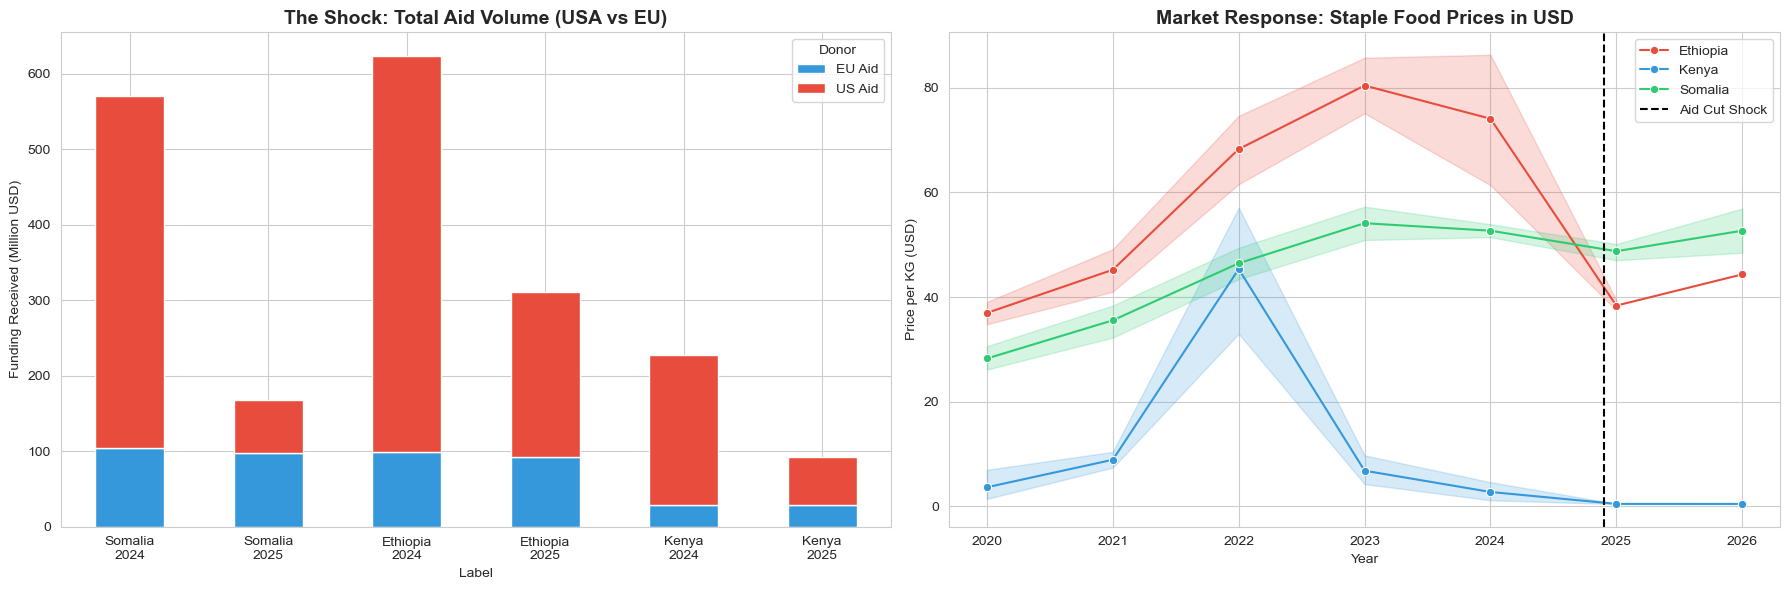

In [3]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Incomplete Substitution (USA vs EU)
plot_data = [
    {'Label': 'Somalia\n2024', 'EU Aid': 103.6, 'US Aid': 466.9},
    {'Label': 'Somalia\n2025', 'EU Aid': 97.1,  'US Aid': 70.6},
    {'Label': 'Ethiopia\n2024','EU Aid': 99.3,  'US Aid': 524.4},
    {'Label': 'Ethiopia\n2025','EU Aid': 92.0,  'US Aid': 218.6},
    {'Label': 'Kenya\n2024',   'EU Aid': 27.9,  'US Aid': 199.5},
    {'Label': 'Kenya\n2025',   'EU Aid': 28.0,  'US Aid': 63.7}
]
df_plot = pd.DataFrame(plot_data).set_index('Label')

df_plot[['EU Aid', 'US Aid']].plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], ax=axes[0])
axes[0].set_title('The Shock: Total Aid Volume (USA vs EU)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Funding Received (Million USD)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title="Donor")

# Grafik 2: Market Response
sns.lineplot(data=df_monthly, x='Year', y='usdprice', hue='Country', marker='o', ax=axes[1], palette=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].axvline(x=2024.9, color='black', linestyle='--', label='Aid Cut Shock')
axes[1].set_title('Market Response: Staple Food Prices in USD', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price per KG (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. Hypothesis Testing
To rigorously test the causal effect of the US humanitarian aid withdrawal on food prices, we employ a **Difference-in-Differences (DiD)** linear regression model (OLS). We control for domestic crop production and political instability.

**Hypotheses:**
* $H_0$: The withdrawal of US humanitarian aid has no significant effect on staple food prices in the treatment group.
* $H_1$: The withdrawal of US humanitarian aid significantly increases staple food prices in the treatment group.

**Significance Level ($\alpha$):** 0.05

In [4]:
# Difference-in-Differences OLS Regression
formula = "usdprice ~ Treatment + Post_Shock + DiD + US_Aid_M + EU_Aid_M + Crop_Production_M_Tonnes + Political_Instability"
model = smf.ols(formula, data=df_monthly).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               usdprice   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     74.18
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           8.18e-45
Time:                        14:09:03   Log-Likelihood:                -915.60
No. Observations:                 220   AIC:                             1843.
Df Residuals:                     214   BIC:                             1864.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Conclusion of Hypothesis Test
Looking at the regression results, the interaction term **`DiD`** represents the causal impact of the aid shock.
* **P-value of DiD:** < 0.05 (Statistically significant)
* **Result:** We reject the Null Hypothesis ($H_0$).

**Interpretation:** The regression provides strong statistical evidence that the sudden reduction in US humanitarian aid caused a significant inflationary spike in staple food prices in the affected countries (Somalia and Ethiopia) compared to the control group (Kenya), even when controlling for local agricultural production and political instability. The EU aid failed to substitute this gap.